# Gather the quantitative impact

In [1]:
import datetime as dt
import geopandas as gpd
from matplotlib import pyplot as plt
from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.impact_def import *
from src.accuracy import *

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
#load data (model)
model = "meta-llama_llama-4-scout-17b-16e-instruct"
#"llama-3.1-8b-instant"
# #"llama-3.3-70b-versatile"
# "meta-llama_llama-4-scout-17b-16e-instruct"
res_savename_ext = f"post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
#f"post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
#f"post_processed_flags_labelled_reports_{model}_v230925"
#"post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_v050925_21rep_meta-llama_llama-4-scout-17b-16e-instruct"
#"post_processed_labelled_reports_test_date_meta-llama_llama-4-scout-17b-16e-instruct_v180925"
extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))

split_lowest = True
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 ="_v260925"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+suffix2+".gpkg"))#(res_savename_ext+suffix+suffix2+".gpkg")

In [11]:
extracted_df.head()

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,country_iso3_kw,unit_type,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox,geometry
0,Affected People,7500000.0,NaN,NaN,exact,people,['These two hurricanes affected more than7.5 m...,"['Guatemala', 'Honduras', 'Nicaragua']",[],['These two hurricanes affected more than7.5 m...,...,PAN,other,ADM_0,0,0,"['Guatemala', 'Nicaragua', 'Honduras']","['Guatemala', 'Nicaragua', 'Honduras']","['GTM', 'NIC', 'HND']",NaN,"MULTIPOLYGON (((-87.62558 13.28992, -87.62209 ..."
1,Affected People,5000000.0,NaN,NaN,exact,people,['These departments are home to some five mill...,['Guatemala'],"['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuete...",['These departments are home to some five mill...,...,PAN,other,ADM_1,0,0,"['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuete...","['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuete...",['GTM'],NaN,"MULTIPOLYGON (((-89.35679 14.42262, -89.35685 ..."
2,Affected People,4700000.0,NaN,NaN,exact,people,['Approximately4.7 million people5 were affect...,['Honduras'],"['Sula Valley', 'Copán', 'Choluteca', 'Comayag...",['Hurricane Iota affected communities in the S...,...,PAN,other,ADM_0,3,1,"['Guatemala', 'Copán', 'Choluteca', 'Cortés', ...","['Guatemala', 'Honduras', 'Guatemala', 'Guatem...","['GTM', 'HND']",NaN,"MULTIPOLYGON (((-87.61326 13.2833, -87.6151 13..."
3,Affected People,NaN,NaN,NaN,exact,None,['Approximately4.7 million people5 were affect...,['Honduras'],"['Sula Valley', 'Copán', 'Choluteca', 'Comayag...",['Hurricane Iota affected communities in the S...,...,PAN,other,ADM_1,0,1,"['Copán', 'Choluteca', 'Cortés', 'Atlántida', ...","['Copán', 'Guatemala', 'Quiché', 'Suchitepéque...","['HND', 'GTM']",NaN,"MULTIPOLYGON (((-88.81259 15.26273, -88.75929 ..."
4,Affected People,NaN,NaN,NaN,exact,None,['Approximately4.7 million people5 were affect...,['Honduras'],"['Sula Valley', 'Copán', 'Choluteca', 'Comayag...",['Hurricane Iota affected communities in the S...,...,PAN,other,ADM_2,0,1,"['Choluteca', 'Atlántida', 'Colón']","['Guatemala', 'Quiché', 'El Palmar']",['GTM'],NaN,"MULTIPOLYGON (((-90.83723 16.79571, -90.83745 ..."


In [3]:
extracted_df_copy = extracted_df.copy()

In [4]:
def union_lists(series):
    """Merge lists or single strings into a unique flat list."""
    all_items = []
    for x in series:
        if isinstance(x, list):
            all_items.extend(x)
        elif pd.notna(x):
            all_items.append(x)
    return list(set(all_items)) if all_items else np.nan

In [5]:
# Split qualitative (no numeric info) and quantitative (has at least one numeric)
mask_quant = extracted_df_copy[['impactValue', 'impactValueMin', 'impactValueMax']].notna().any(axis=1)
df_quant = extracted_df_copy[mask_quant].copy()
df_qual = extracted_df_copy[~mask_quant].copy()

In [6]:
# Group qualitative rows by impactSubtype and locationLowestAdmin
df_qual_grouped = (
    df_qual.groupby(['appealCode', 'impactSubtype', 'locationLowestAdmin'], dropna=False)
    .agg({
        'impactValue': 'first',
        'impactValueMin': 'first',
        'impactValueMax': 'first',
        'impactValuePrecision': 'first',
        'impactUnit': 'first',
        'valueAnnotation': union_lists,
        'country': union_lists,
        'location': union_lists,
        'locationAnnotation': union_lists,
        'country_iso3_kw': union_lists,
        'unit_type': 'first',
        'geocoding_country_flag': 'max',
        'geocoding_osm_flag': 'max',
        'locationOsm': union_lists,
        'locationPolygon': union_lists,
        'iso3_code': union_lists,
        'impactValueApprox': 'first',
        'geometry': 'first',
    })
    .reset_index()
)

In [8]:
count_grouped = df_qual_grouped['appealCode'].value_counts().sort_index()
count_raw = df_qual['appealCode'].value_counts().sort_index()

count_grouped, count_raw = count_grouped.align(count_raw, fill_value=0)

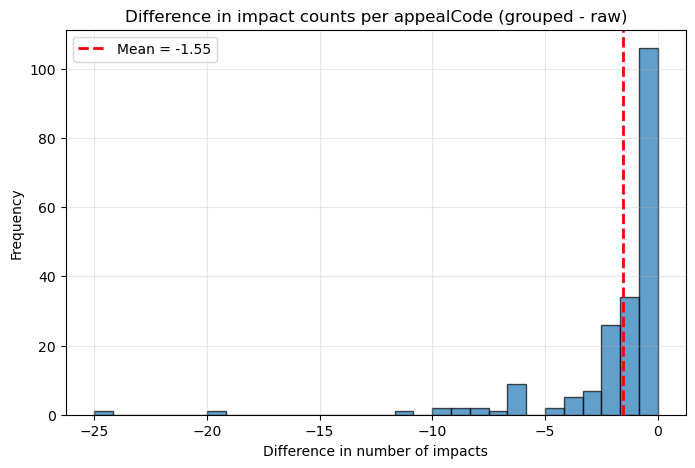

In [12]:
diff_counts = count_grouped - count_raw

# Compute mean difference
mean_diff = diff_counts.mean()

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(diff_counts, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(mean_diff, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_diff:.2f}")
plt.title("Difference in impact counts per appealCode (grouped - raw)")
plt.xlabel("Difference in number of impacts")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)

# Add text annotation
# plt.text(mean_diff-, plt.ylim()[1]*0.9, f"Mean = {mean_diff:.2f}", color='red', ha='left')

plt.show()